<div style="background:linear-gradient(135deg,#06184a,#0b63ce);padding:32px;border-radius:22px;color:white">
  <h1 style="margin:0;font-size:42px">🐱🐶 CNN Classroom Lab</h1>
  <h2 style="margin:8px 0 0 0;font-weight:500">Cats vs. Dogs demo by Dr. Mali (TKAI Lab, USF) </h2>
  <p style="font-size:18px;margin-top:18px">
    This should ideally work with free collab account students have at summer school USF
  </p>
</div>

<br>

<div style="display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:12px">
  <div style="background:#eef6ff;padding:15px;border-radius:13px">
    <b>🚫 No dataset download, to avoid space issue with drive</b><br>
    The tiny image set is embedded inside this notebook.
  </div>
  <div style="background:#effcf7;padding:15px;border-radius:13px">
    <b>💻 CPU friendly, in case GPU becomes unavailable </b><br>
    A GPU is optional rather than required.
  </div>
  <div style="background:#fff6e5;padding:15px;border-radius:13px">
    <b>⚡ Short training</b><br>
    A small CNN and a limited number of training steps.
  </div>
</div>

### What students will learn

- Images as numbers and RGB channels
- Convolution filters and feature maps
- A normal CNN built from scratch
- Training and validation curves
- Confusion matrix and classification report
- Correct predictions, mistakes, and confidence
- Learned filters and internal activations
- A simple Grad-CAM explanation

> **Important:** This is a small instructional dataset used for summer school conducted at USF during summer 2026 session. It demonstrates the complete workflow, but its accuracy is not evidence of a production-quality cat–dog classifier.

<div style="border-left:7px solid #198754;background:#effcf7;padding:15px 20px;border-radius:12px">
<b>Recommended workflow</b><br>
Everyone please first <b>Connect → Change Runtime type → GPU </b>, then use <b>Runtime → Run all</b>. No upload dialog and no external dataset download will interrupt the run.
Keep the default settings for now. What I would like is that students experiment with epochs and network size afterward <b> Play with it → It's fun and your first step into Deep Learning </b>.
</div>

## 1. Setup

In [1]:
import io
import base64
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf

from IPython.display import display, HTML
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

mpl.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 105,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.20,
})

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))
print("The default classroom settings also work on CPU.")

TensorFlow: 2.20.0
GPU available: True
The default classroom settings also work on CPU.


In [2]:
def info_card(title, message, color="#0b63ce"):
    display(HTML(
        f'<div style="border-left:7px solid {color};background:#f7fbff;'
        f'padding:14px 18px;border-radius:12px;margin:10px 0">'
        f'<b style="font-size:17px;color:{color}">{title}</b><br>{message}</div>'
    ))

info_card(
    "Why no large download?",
    "Thirty students downloading the same large archive can take good amount of time->Space/permission/Compute restriction. "
    "This notebook carries a tiny balanced image set inside the notebook itself."
)

## 2. Unpack the embedded cat-and-dog images

In [3]:
DATASET_B64 = (
    "..."
)

raw_bytes = base64.b64decode(DATASET_B64)
with np.load(io.BytesIO(raw_bytes), allow_pickle=False) as data:
    all_images = data["images"]
    all_labels = data["labels"]
    all_splits = data["splits"]
    all_names = data["names"]

CLASS_NAMES = ["Cat", "Dog"]
IMG_SIZE = (64, 64)

print("Embedded images:", len(all_images))
print("Image shape:", all_images.shape[1:])
print("External dataset download required: No")

Embedded images: 26
Image shape: (64, 64, 3)
External dataset download required: No


,split,class,base images
0,train,Cat,8
1,train,Dog,8
2,val,Cat,2
3,val,Dog,2
4,test,Cat,3
5,test,Dog,3


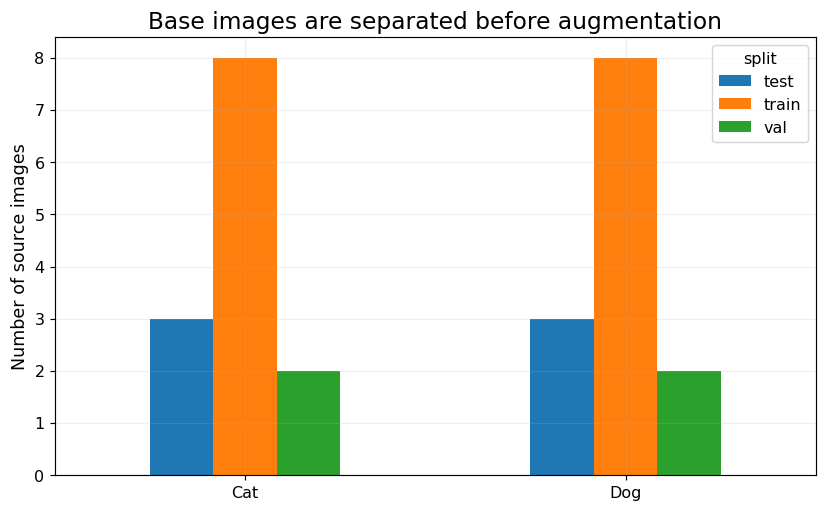

In [4]:
summary_rows = []
for split_name in ["train", "val", "test"]:
    for label_id, class_name in enumerate(CLASS_NAMES):
        count = int(np.sum((all_splits == split_name) & (all_labels == label_id)))
        summary_rows.append({
            "split": split_name,
            "class": class_name,
            "base images": count,
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.pivot(
    index="class",
    columns="split",
    values="base images",
).plot(kind="bar", rot=0, figsize=(8, 5))

plt.title("Base images are separated before augmentation")
plt.ylabel("Number of source images")
plt.xlabel("")
plt.tight_layout()
plt.show()

The base images are split first. Training augmentation is applied **after** the split, so test images do not appear in training.
The dataset is intentionally tiny; the goal is to show the workflow reliably during class.

## 3. Look at the embedded images

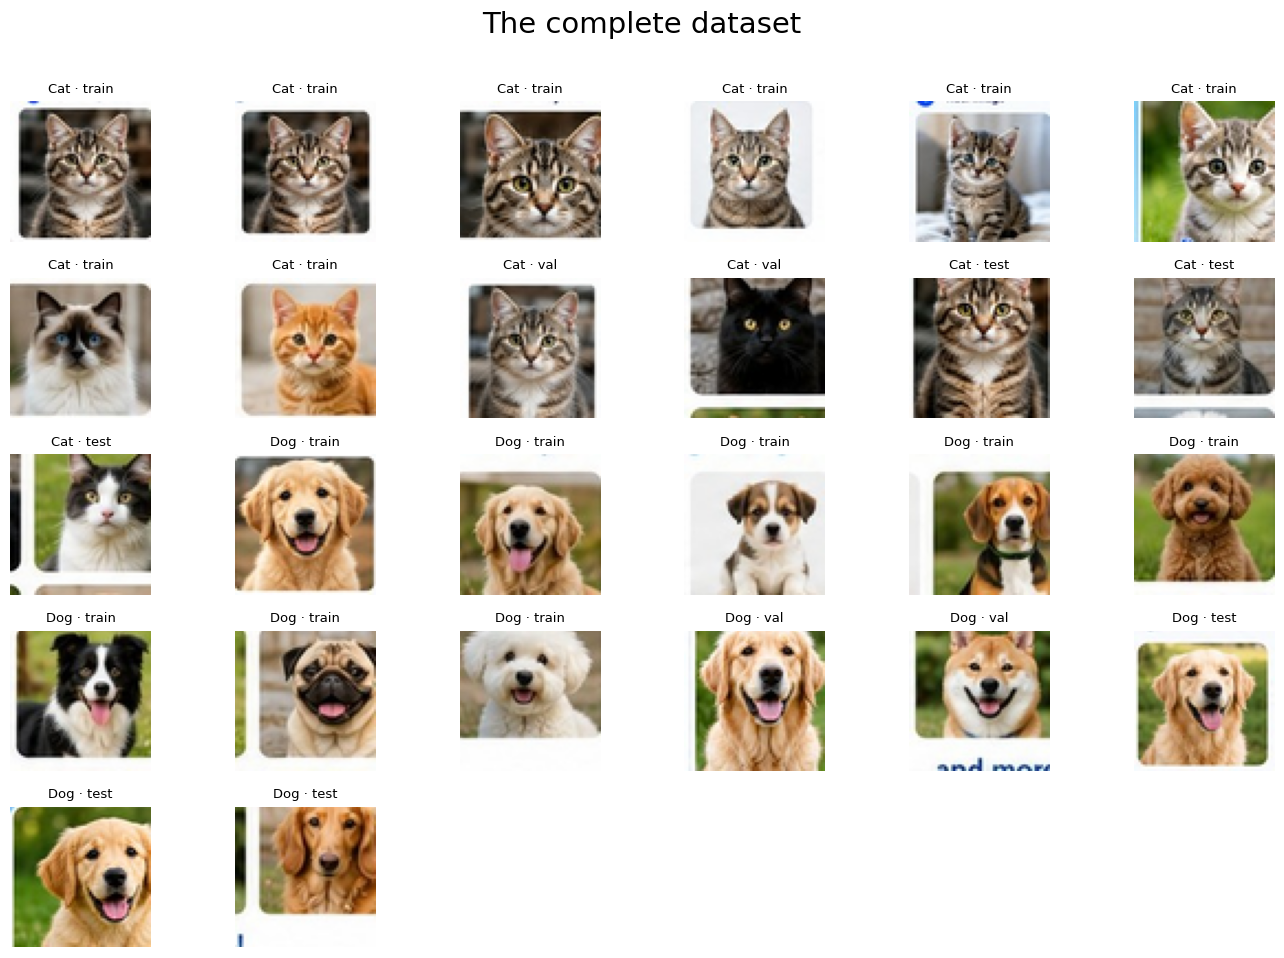

In [5]:
plt.figure(figsize=(13, 9))

for i in range(len(all_images)):
    ax = plt.subplot(5, 6, i + 1)
    plt.imshow(all_images[i])
    split = str(all_splits[i])
    label = CLASS_NAMES[int(all_labels[i])]
    plt.title(f"{label} · {split}", fontsize=9)
    plt.axis("off")

plt.suptitle("The complete dataset", fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

### Notice the diversity

Some images show close-up faces; others show the full animal. Breeds, fur colors, and backgrounds vary.
The dataset is still far smaller and less diverse than a real-world training dataset.

## 4. Images are blocks of RGB numbers

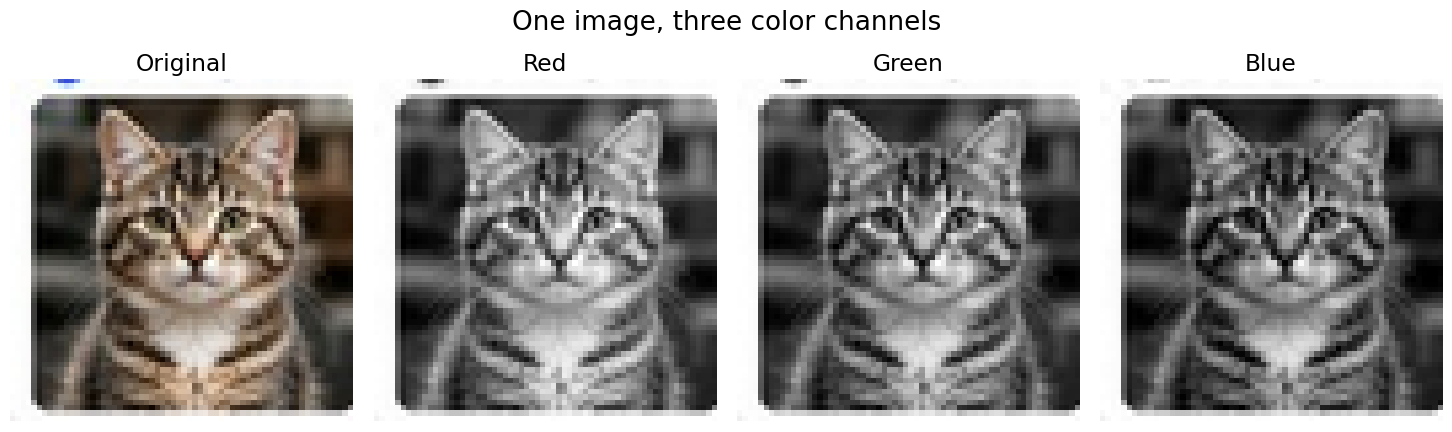

One pixel near the center stores RGB values: [58, 31, 17]


In [6]:
sample_image = all_images[0]

channel_titles = ["Original", "Red", "Green", "Blue"]
channel_data = [
    sample_image,
    sample_image[:, :, 0],
    sample_image[:, :, 1],
    sample_image[:, :, 2],
]

plt.figure(figsize=(14, 4))
for i, (title, image) in enumerate(zip(channel_titles, channel_data), start=1):
    ax = plt.subplot(1, 4, i)
    if image.ndim == 2:
        plt.imshow(image, cmap="gray")
    else:
        plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.suptitle("One image, three color channels", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("One pixel near the center stores RGB values:",
      sample_image[32, 32].tolist())

## 5. Apply hand-designed filters

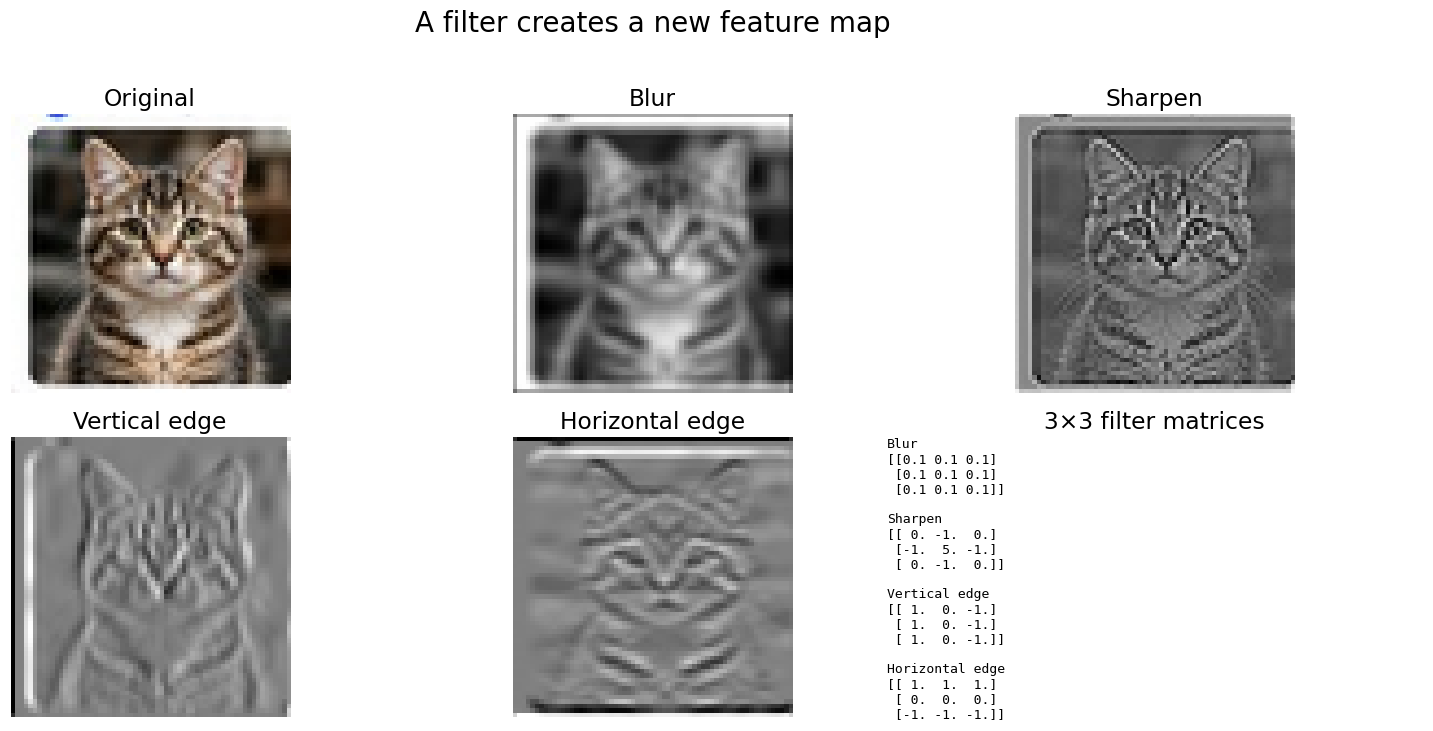

In [7]:
FILTERS = {
    "Blur": np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
    ], dtype=np.float32) / 9.0,

    "Sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0],
    ], dtype=np.float32),

    "Vertical edge": np.array([
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1],
    ], dtype=np.float32),

    "Horizontal edge": np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1],
    ], dtype=np.float32),
}

def apply_filter(image_uint8, kernel):
    image = tf.cast(image_uint8, tf.float32) / 255.0
    gray = tf.image.rgb_to_grayscale(image)[tf.newaxis, ...]
    kernel_tf = tf.constant(
        kernel[:, :, np.newaxis, np.newaxis],
        dtype=tf.float32,
    )
    output = tf.nn.conv2d(gray, kernel_tf, strides=1, padding="SAME")
    return output[0, :, :, 0].numpy()

def normalize_for_display(array):
    minimum = np.min(array)
    maximum = np.max(array)
    return (array - minimum) / (maximum - minimum + 1e-8)

plt.figure(figsize=(15, 7))

ax = plt.subplot(2, 3, 1)
plt.imshow(sample_image)
plt.title("Original")
plt.axis("off")

for plot_number, (name, kernel) in enumerate(FILTERS.items(), start=2):
    filtered = apply_filter(sample_image, kernel)
    ax = plt.subplot(2, 3, plot_number)
    plt.imshow(normalize_for_display(filtered), cmap="gray")
    plt.title(name)
    plt.axis("off")

ax = plt.subplot(2, 3, 6)
plt.axis("off")
matrix_text = "\n\n".join(
    f"{name}\n{np.array2string(kernel, precision=1, suppress_small=True)}"
    for name, kernel in FILTERS.items()
)
plt.text(0, 1, matrix_text, va="top", family="monospace", fontsize=9)
plt.title("3×3 filter matrices")

plt.suptitle("A filter creates a new feature map", fontsize=19, y=1.02)
plt.tight_layout()
plt.show()

A filter slides across the image. At every location it performs **multiply + add**.
CNNs do not keep these hand-designed filters; they learn useful filters from examples.

## 6. Prepare train, validation, and test variants

In [8]:
train_mask = all_splits == "train"
val_mask = all_splits == "val"
test_mask = all_splits == "test"

x_train_base = all_images[train_mask]
y_train_base = all_labels[train_mask].astype("float32")

x_val_base = all_images[val_mask]
y_val_base = all_labels[val_mask].astype("float32")

x_test_base = all_images[test_mask]
y_test_base = all_labels[test_mask].astype("float32")

def make_eval_variants(images, labels):
    variant_images = []
    variant_labels = []

    for image, label in zip(images, labels):
        image_tf = tf.convert_to_tensor(image)

        original = image_tf
        flipped = tf.image.flip_left_right(image_tf)

        center = tf.image.central_crop(
            tf.cast(image_tf, tf.float32),
            central_fraction=0.84,
        )
        center = tf.image.resize(center, IMG_SIZE)
        center = tf.cast(tf.clip_by_value(center, 0, 255), tf.uint8)

        for variant in [original, flipped, center]:
            variant_images.append(variant.numpy())
            variant_labels.append(label)

    return (
        np.asarray(variant_images, dtype=np.uint8),
        np.asarray(variant_labels, dtype=np.float32),
    )

x_val, y_val = make_eval_variants(x_val_base, y_val_base)
x_test, y_test = make_eval_variants(x_test_base, y_test_base)

print("Training base images:", len(x_train_base))
print("Validation variants:", len(x_val))
print("Test variants:", len(x_test))

Training base images: 16
Validation variants: 12
Test variants: 18


Validation and test variants are generated only from base images that were never placed in the training split.
The extra variants make the plots and confusion matrix easier to read while preserving source-image separation.

## 7. See random training augmentation

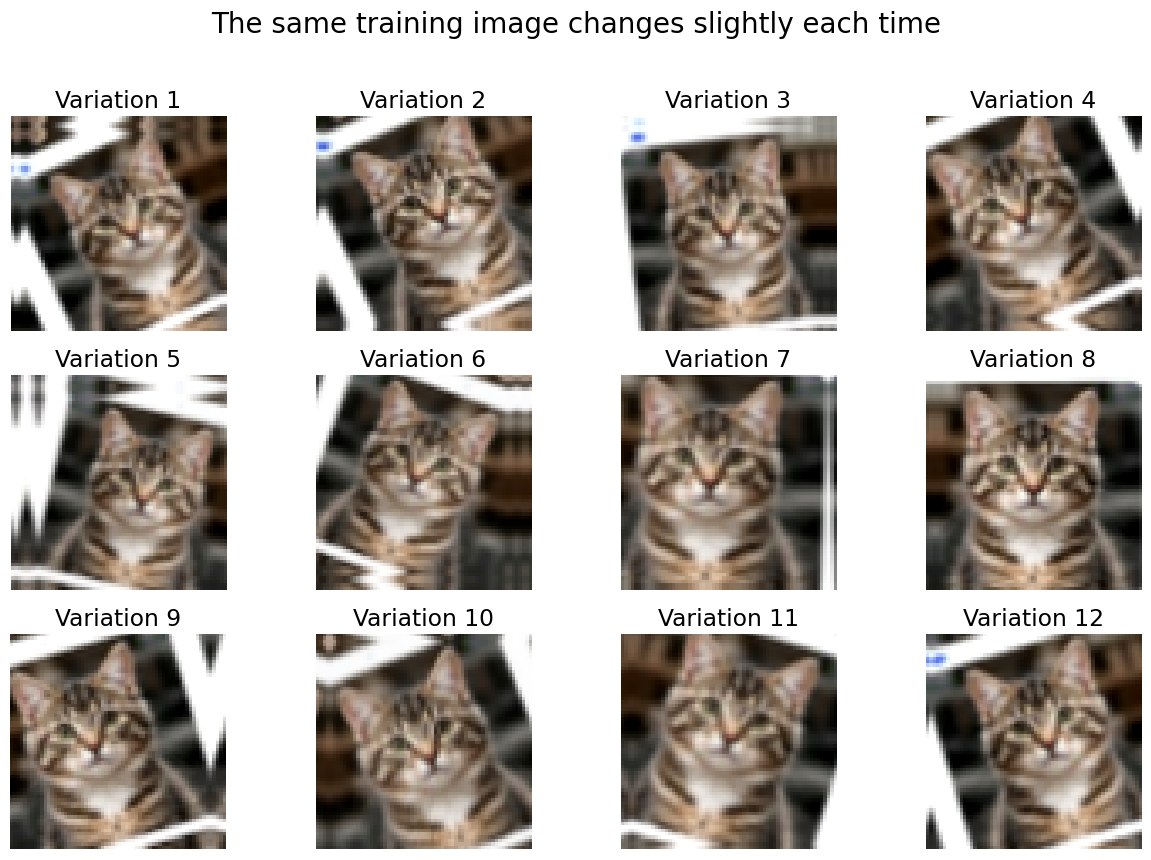

In [9]:
data_augmentation = keras.Sequential(
    [
        # Explicit input shape prevents Keras from inferring the wrong rank
        # when the augmentation pipeline is first called.
        layers.Input(shape=(64, 64, 3)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.07),
        layers.RandomZoom(0.12),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomContrast(0.12),
    ],
    name="augmentation",
)

plt.figure(figsize=(12, 8))

# Augmentation layers expect a batch of images, so use shape (1, 64, 64, 3)
# and then select the first augmented image for display.
sample_batch = tf.cast(x_train_base[0:1], tf.float32)

for i in range(12):
    changed_batch = data_augmentation(sample_batch, training=True)
    changed = changed_batch[0]

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(changed, 0, 255), tf.uint8))
    plt.title(f"Variation {i + 1}")
    plt.axis("off")

plt.suptitle(
    "The same training image changes slightly each time",
    fontsize=19,
    y=1.02,
)
plt.tight_layout()
plt.show()

<div style="border-left:7px solid #198754;background:#effcf7;padding:14px 18px;border-radius:12px">
<b>Keras shape fix</b><br>
The augmentation pipeline is now explicitly defined for batched images with shape
<code>(batch, 64, 64, 3)</code>. The preview cell also adds a batch dimension before calling it.
</div>

## 8. Build a small, normal CNN

In [10]:
inputs = keras.Input(shape=(64, 64, 3), name="image")

x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255, name="rescale")(x)

x = layers.Conv2D(16, 3, padding="same", activation="relu", name="conv1")(x)
x = layers.MaxPooling2D(name="pool1")(x)

x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2")(x)
x = layers.MaxPooling2D(name="pool2")(x)

x = layers.Conv2D(48, 3, padding="same", activation="relu", name="conv3")(x)
x = layers.GlobalAveragePooling2D(name="global_average_pool")(x)

x = layers.Dense(32, activation="relu", name="features")(x)
x = layers.Dropout(0.25, name="dropout")(x)

outputs = layers.Dense(1, activation="sigmoid", name="dog_probability")(x)

model = keras.Model(inputs, outputs, name="classroom_cat_dog_cnn")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

model.summary()

Model: "classroom_cat_dog_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dog_probability (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,561 (80.32 KB)

 Trainable params: 20,561 (80.32 KB)

 Non-trainable params: 0 (0.00 B)

This is a real CNN, just intentionally small:

- convolution layers learn local patterns,
- pooling reduces image size,
- a dense layer combines features,
- sigmoid outputs a dog probability from 0 to 1.

## 9. Let's start the process

In [11]:
BATCH_SIZE = 32
REPEAT_FACTOR = 20
EPOCHS = 7

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((x_train_base, y_train_base))
    .shuffle(len(x_train_base), seed=SEED, reshuffle_each_iteration=True)
    .repeat(REPEAT_FACTOR)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

STEPS_PER_EPOCH = int(np.ceil(
    len(x_train_base) * REPEAT_FACTOR / BATCH_SIZE
))

print("Steps per epoch:", STEPS_PER_EPOCH)
print("Epochs:", EPOCHS)
print("Total training steps:", STEPS_PER_EPOCH * EPOCHS)

Steps per epoch: 10
Epochs: 7
Total training steps: 70


The training set is repeated, but augmentation changes the images on each pass.
This gives the CNN enough practice without downloading thousands of files.

## 10. Train

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.5000 - loss: 0.6915 - precision: 0.5000 - recall: 0.3812 - val_accuracy: 0.5833 - val_loss: 0.6789 - val_precision: 0.5455 - val_recall: 1.0000
Epoch 2/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5969 - loss: 0.6812 - precision: 0.5829 - recall: 0.6812 - val_accuracy: 0.7500 - val_loss: 0.6663 - val_precision: 1.0000 - val_recall: 0.5000
Epoch 3/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6438 - loss: 0.6628 - precision: 0.6575 - recall: 0.6000 - val_accuracy: 1.0000 - val_loss: 0.5776 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6812 - loss: 0.6411 - precision: 0.6726 - recall: 0.7063 - val_accuracy: 1.0000 - val_loss: 0.5107 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7219 - loss: 0.5929 - precision: 0.7483 - recall: 0.6687 - val_accuracy: 1.0000 - val_loss: 0.3845 - val

## 11. Training and validation graphs

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
epoch,,,,,,,,
1,0.500,0.691,0.500,0.381,0.583,0.679,0.545,1.000
2,0.597,0.681,0.583,0.681,0.750,0.666,1.000,0.500
3,0.644,0.663,0.658,0.600,1.000,0.578,1.000,1.000
4,0.681,0.641,0.673,0.706,1.000,0.511,1.000,1.000
5,0.722,0.593,0.748,0.669,1.000,0.384,1.000,1.000
6,0.756,0.548,0.750,0.769,0.917,0.366,1.000,0.833
7,0.791,0.519,0.772,0.825,1.000,0.268,1.000,1.000


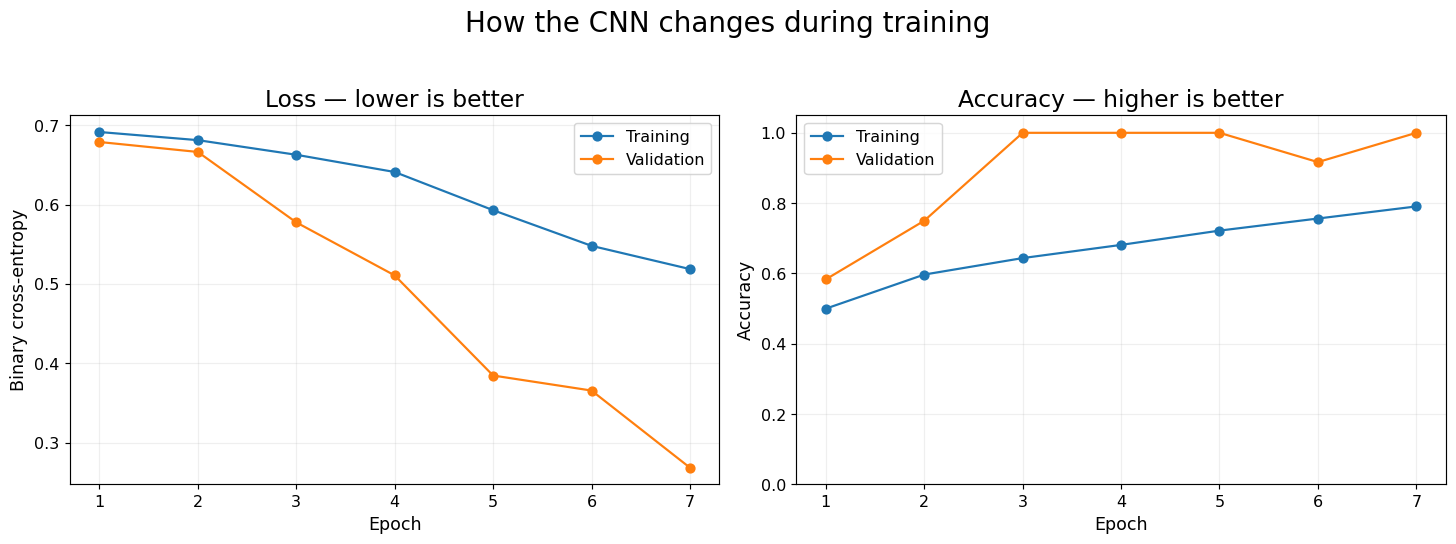

In [13]:
history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

display(history_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df.index, history_df["loss"], marker="o", label="Training")
axes[0].plot(history_df.index, history_df["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss — lower is better")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].plot(history_df.index, history_df["accuracy"], marker="o", label="Training")
axes[1].plot(history_df.index, history_df["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("Accuracy — higher is better")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle("How the CNN changes during training", fontsize=19, y=1.03)
plt.tight_layout()
plt.show()

With such a small dataset, curves may jump around. That is an authentic lesson:
small datasets create uncertainty, and one run may differ from another.

## 12. Evaluate on unseen source images

In [14]:
test_metrics = model.evaluate(test_ds, return_dict=True, verbose=0)
display(pd.DataFrame({
    "metric": list(test_metrics.keys()),
    "value": list(test_metrics.values()),
}).style.format({"value": "{:.3f}"}))

dog_probabilities = model.predict(x_test, verbose=0).reshape(-1)
predicted_labels = (dog_probabilities >= 0.5).astype(int)
true_labels = y_test.astype(int)

,metric,value
0,accuracy,0.833
1,loss,0.335
2,precision,0.750
3,recall,1.000


## 13. Confusion matrix

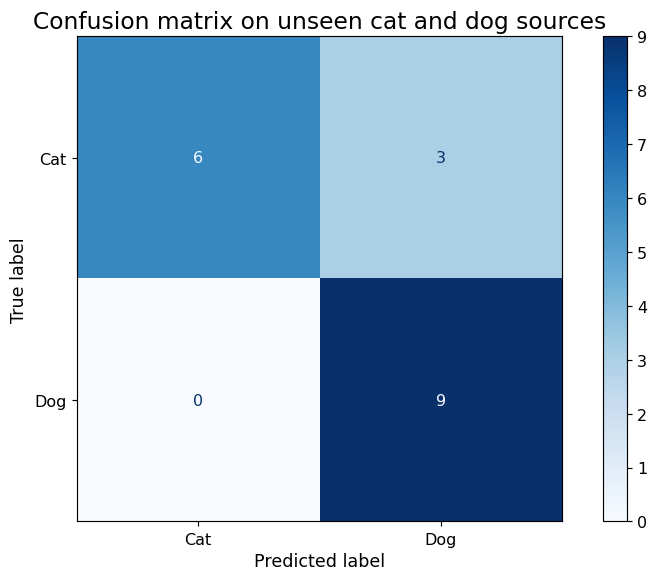

In [15]:
cm = confusion_matrix(true_labels, predicted_labels)

display_plot = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)
display_plot.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix on unseen cat and dog sources")
plt.grid(False)
plt.show()

,precision,recall,f1-score,support
Cat,1.000,0.667,0.800,9.000
Dog,0.750,1.000,0.857,9.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.875,0.833,0.829,18.000
weighted avg,0.875,0.833,0.829,18.000


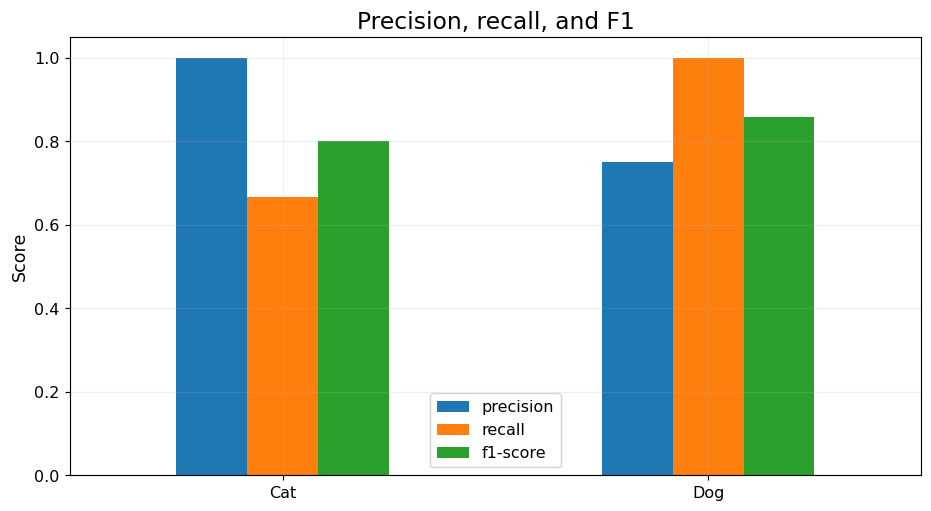

In [16]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
display(report_df.round(3))

report_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]].plot(
    kind="bar",
    rot=0,
    ylim=(0, 1.05),
    figsize=(9, 5),
)
plt.title("Precision, recall, and F1")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 14. View every test prediction

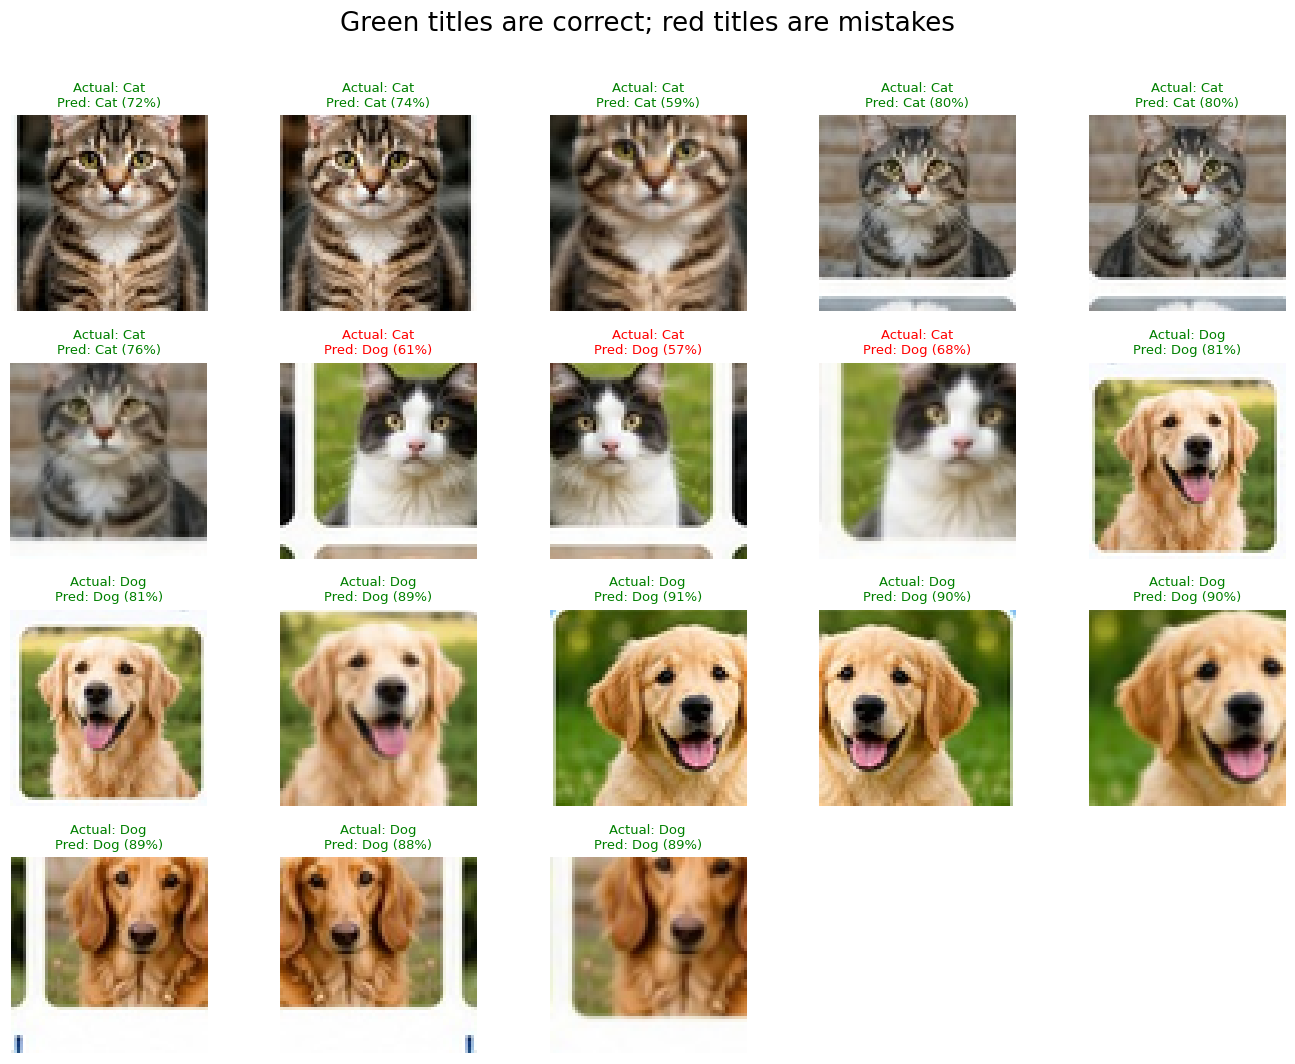

In [17]:
plt.figure(figsize=(13, 10))

for i, image in enumerate(x_test):
    ax = plt.subplot(4, 5, i + 1)

    actual = CLASS_NAMES[int(true_labels[i])]
    predicted = CLASS_NAMES[int(predicted_labels[i])]

    probability_dog = float(dog_probabilities[i])
    confidence = (
        probability_dog
        if predicted == "Dog"
        else 1.0 - probability_dog
    )

    plt.imshow(image)
    plt.title(
        f"Actual: {actual}\nPred: {predicted} ({confidence:.0%})",
        color="green" if actual == predicted else "red",
        fontsize=9,
    )
    plt.axis("off")

plt.suptitle("Green titles are correct; red titles are mistakes", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## 15. Confidence plot

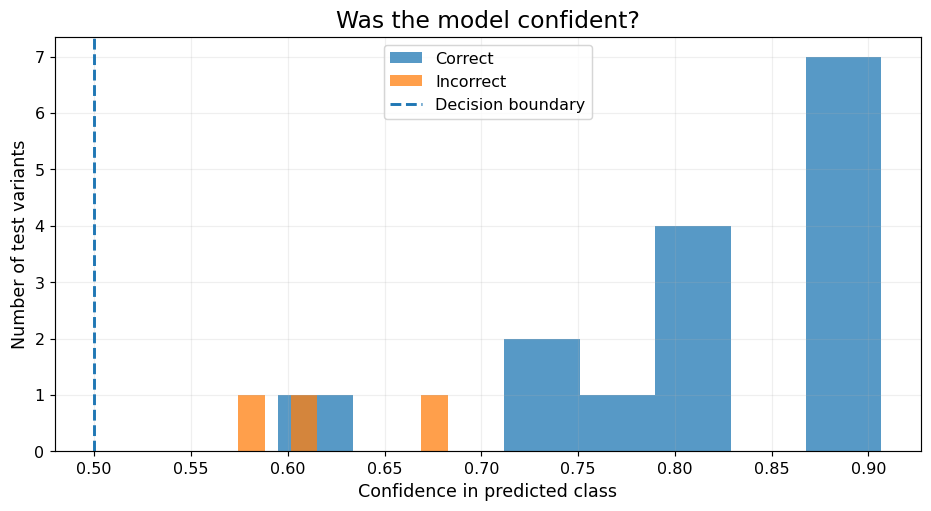

In [18]:
confidence = np.where(
    predicted_labels == 1,
    dog_probabilities,
    1.0 - dog_probabilities,
)
correct = predicted_labels == true_labels

plt.figure(figsize=(9, 5))
plt.hist(confidence[correct], bins=8, alpha=0.75, label="Correct")
if np.any(~correct):
    plt.hist(confidence[~correct], bins=8, alpha=0.75, label="Incorrect")
plt.axvline(0.5, linestyle="--", linewidth=2, label="Decision boundary")
plt.xlabel("Confidence in predicted class")
plt.ylabel("Number of test variants")
plt.title("Was the model confident?")
plt.legend()
plt.tight_layout()
plt.show()

A model can be confident and still be wrong. Confidence is a score produced by the model—not a guarantee.

## 16. Look at learned first-layer filters

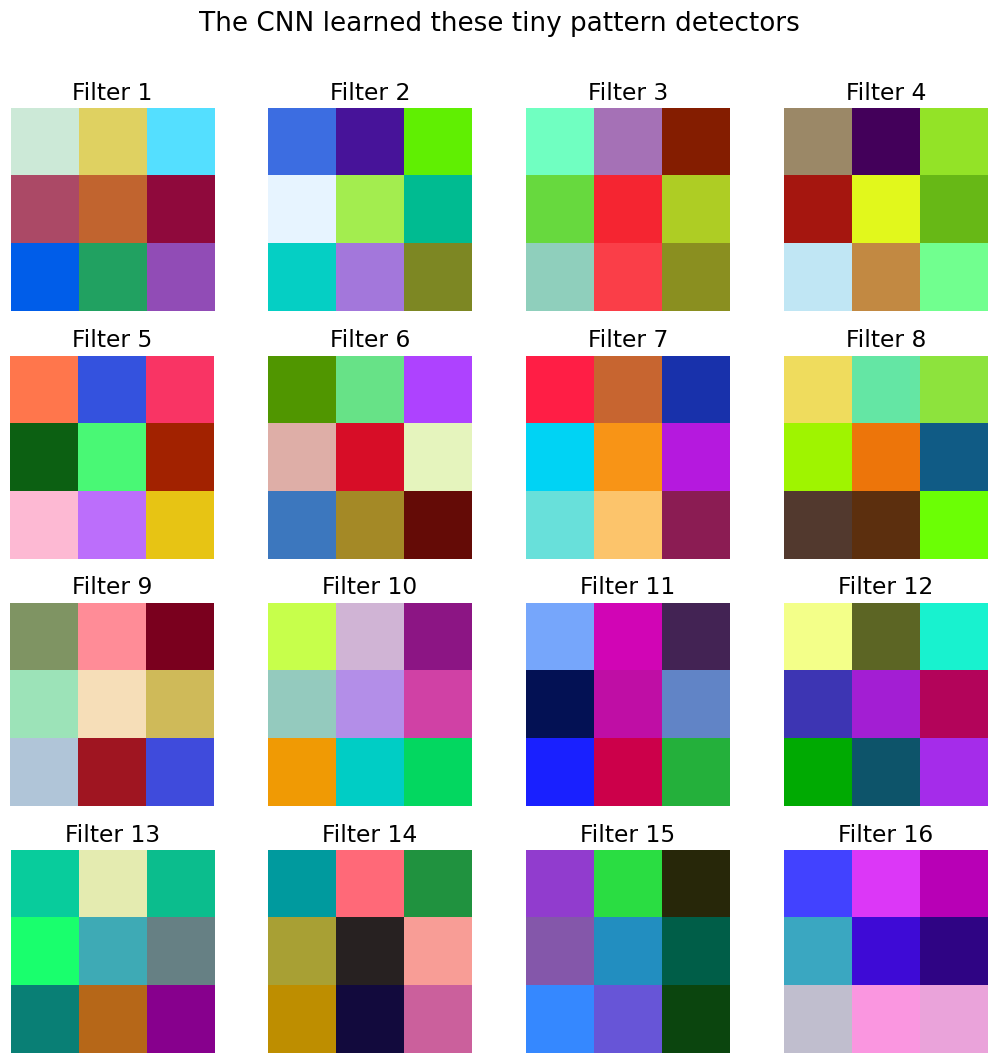

In [19]:
conv1_weights, conv1_biases = model.get_layer("conv1").get_weights()

def normalize_image(array):
    minimum = np.min(array)
    maximum = np.max(array)
    return (array - minimum) / (maximum - minimum + 1e-8)

plt.figure(figsize=(10, 10))
for i in range(conv1_weights.shape[-1]):
    learned_filter = normalize_image(conv1_weights[:, :, :, i])

    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(learned_filter)
    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.suptitle("The CNN learned these tiny pattern detectors", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## 17. Feature maps inside the CNN

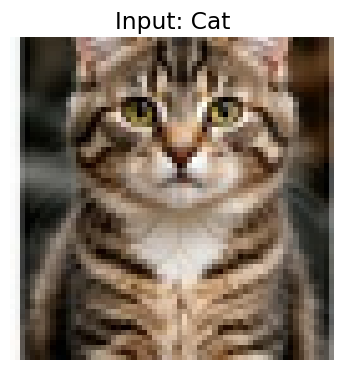

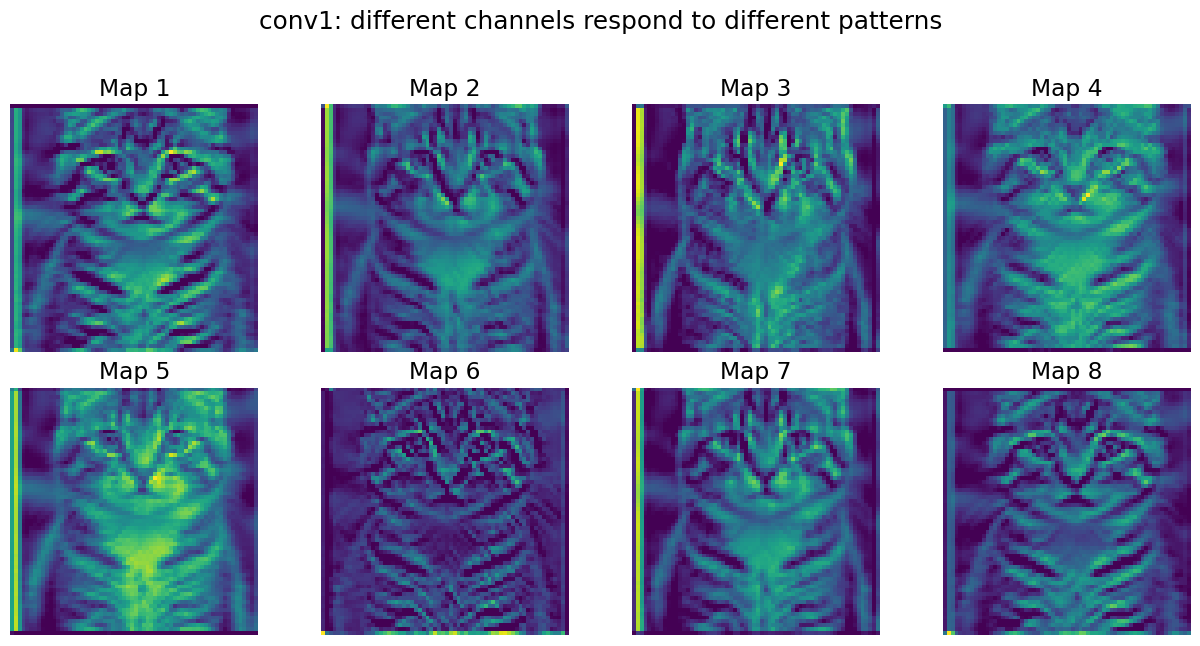

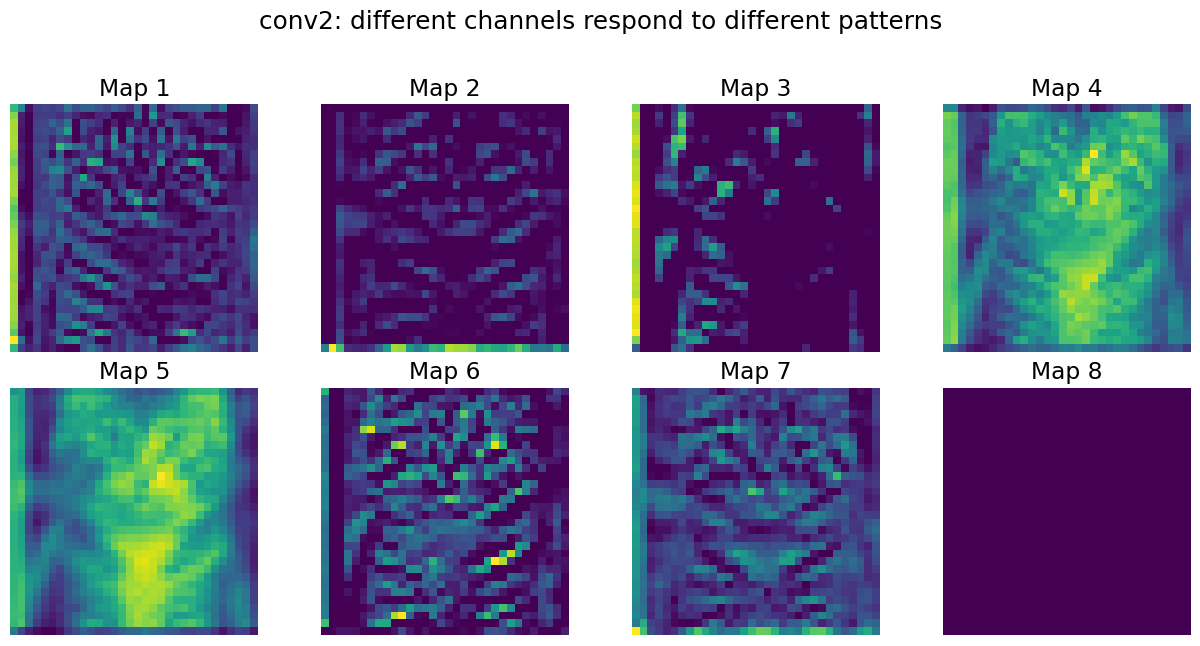

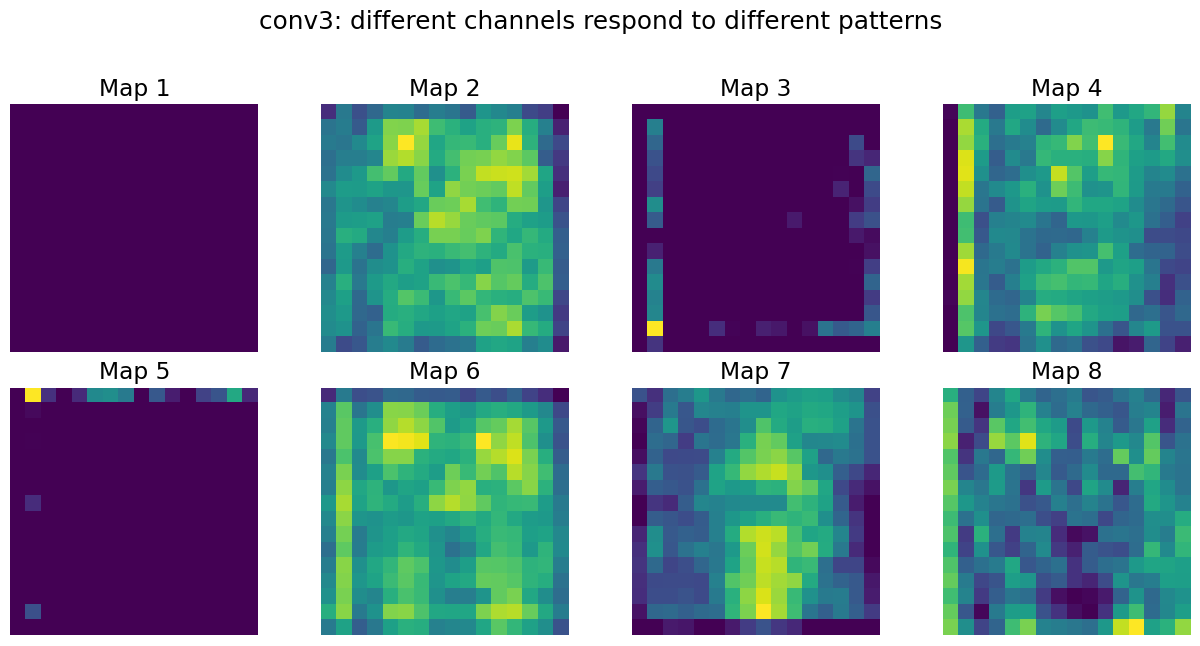

In [20]:
activation_model = keras.Model(
    model.input,
    [
        model.get_layer("conv1").output,
        model.get_layer("conv2").output,
        model.get_layer("conv3").output,
    ],
)

example = x_test[0]
activation_sets = activation_model.predict(example[np.newaxis, ...], verbose=0)

plt.figure(figsize=(4, 4))
plt.imshow(example)
plt.title(f"Input: {CLASS_NAMES[int(true_labels[0])]}")
plt.axis("off")
plt.show()

for layer_name, activation_set in zip(
    ["conv1", "conv2", "conv3"],
    activation_sets,
):
    feature_maps = activation_set[0]
    number_to_show = min(8, feature_maps.shape[-1])

    plt.figure(figsize=(12, 6))
    for channel in range(number_to_show):
        ax = plt.subplot(2, 4, channel + 1)
        plt.imshow(feature_maps[:, :, channel], cmap="viridis")
        plt.title(f"Map {channel + 1}")
        plt.axis("off")

    plt.suptitle(
        f"{layer_name}: different channels respond to different patterns",
        fontsize=17,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

## 18. Grad-CAM: what region influenced the prediction?

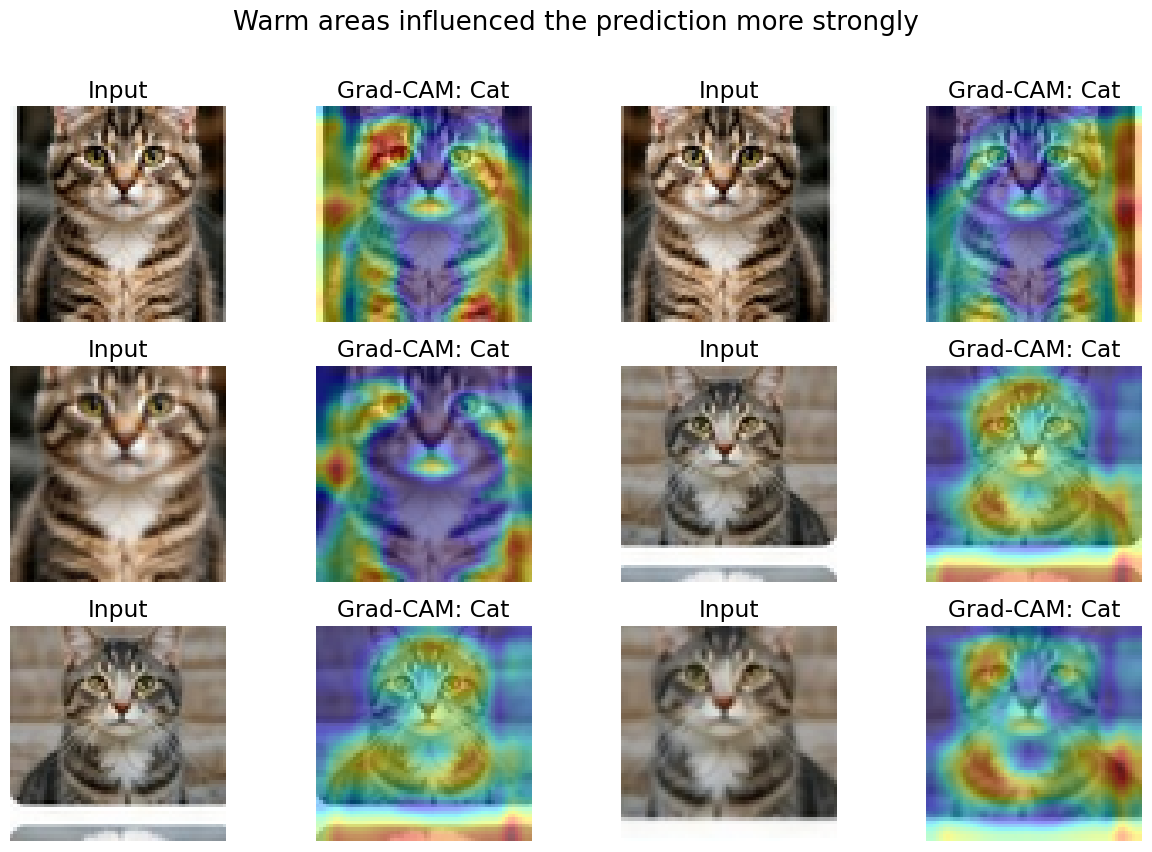

In [21]:
def gradcam_heatmap(image_uint8, trained_model, layer_name="conv3"):
    explanation_model = keras.Model(
        trained_model.inputs,
        [
            trained_model.get_layer(layer_name).output,
            trained_model.output,
        ],
    )

    image_tensor = tf.convert_to_tensor(
        image_uint8[np.newaxis, ...],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        feature_maps, dog_probability = explanation_model(
            image_tensor,
            training=False,
        )

        score = tf.where(
            dog_probability[:, 0] >= 0.5,
            dog_probability[:, 0],
            1.0 - dog_probability[:, 0],
        )

    gradients = tape.gradient(score, feature_maps)
    importance = tf.reduce_mean(gradients, axis=(0, 1, 2))

    feature_maps = feature_maps[0]
    heatmap = tf.reduce_sum(feature_maps * importance, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def overlay_heatmap(image_uint8, heatmap, alpha=0.42):
    resized = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE,
    ).numpy().squeeze()

    colored = plt.get_cmap("jet")(resized)[..., :3]
    original = image_uint8.astype(np.float32) / 255.0
    return np.clip((1 - alpha) * original + alpha * colored, 0, 1)

plt.figure(figsize=(12, 8))

examples_to_show = min(6, len(x_test))
for i in range(examples_to_show):
    heatmap = gradcam_heatmap(x_test[i], model)
    overlay = overlay_heatmap(x_test[i], heatmap)

    ax = plt.subplot(3, 4, 2 * i + 1)
    plt.imshow(x_test[i])
    plt.title("Input")
    plt.axis("off")

    ax = plt.subplot(3, 4, 2 * i + 2)
    plt.imshow(overlay)
    predicted = CLASS_NAMES[int(predicted_labels[i])]
    plt.title(f"Grad-CAM: {predicted}")
    plt.axis("off")

plt.suptitle("Warm areas influenced the prediction more strongly", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

Grad-CAM is a diagnostic visualization, not proof that the network understands the animal as a human does.

## 19. Optional experiment controls

In [22]:
print("Try only after the class demonstration:")
print("1. Change EPOCHS from 7 to 3 or 12 or any number and visualize performance.")
print("2. Remove one convolution layer and check performance.")
print("3. Turn off data augmentation and analyze the outcome.")
print("4. Change the decision threshold from 0.5 to some other number and do the analysis.")
print("5. Compare which change helps or improves validation results.")

Try only after the class demonstration:
1. Change EPOCHS from 7 to 3 or 12 or any number and visualize performance.
2. Remove one convolution layer and check performance.
3. Turn off data augmentation and analyze the outcome.
4. Change the decision threshold from 0.5 to some other number and do the analysis.
5. Compare which change helps or improves validation results.


## 20. Final recap

<div style="display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:13px">
  <div style="background:#eef6ff;padding:17px;border-radius:13px">
    <b>Filters</b><br>
    Small matrices detect local patterns such as edges and textures.
  </div>
  <div style="background:#effcf7;padding:17px;border-radius:13px">
    <b>CNN layers</b><br>
    Deeper layers combine simple features into richer features.
  </div>
  <div style="background:#f6f0ff;padding:17px;border-radius:13px">
    <b>Training</b><br>
    Predictions, loss, and weight updates repeat over several epochs.
  </div>
  <div style="background:#fff6e5;padding:17px;border-radius:13px">
    <b>Evaluation</b><br>
    Validation curves, test predictions, and confusion matrices reveal mistakes.
  </div>
</div>

### Discussion questions

1. Which filter output was easiest to recognize?
2. Did validation performance move smoothly or jump around?
3. Which test animals were difficult, and why?
4. Did Grad-CAM focus on the animal or the background?
5. Why should a production system use a much larger and more diverse dataset?